In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
import os
import tifffile as tf

In [2]:
print (os.getcwd())
path = '../data/mitosis.tif'

/home/mutterer/Downloads/viroidoc_python_image_analysis/notebooks


In [3]:
# Read the 3D image
image = io.imread(path)  
print ("raw data",image.shape)
image = image[:,3,0,:,:]
print ("subset data",image.shape)

raw data (51, 5, 2, 196, 171)
subset data (51, 196, 171)


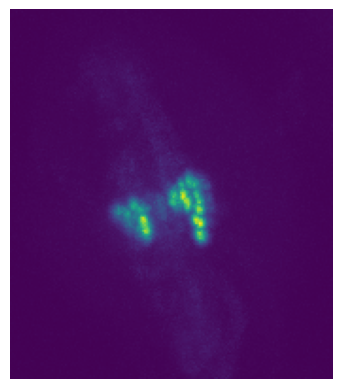

In [9]:
# Calculate the maximum intensity projection along the z-axis
mip = np.max(image, axis=0)

# Display the maximum intensity projection
plt.imshow(mip)
plt.axis('off')
plt.show()

In [5]:
def get_ij_description(s):
    with tf.TiffFile(s) as tiff:
        # Iterate over each page
        page = tiff.pages[0]
        tags = page.tags
    for tag in tags.values():
        #print(f"{tag.name}: {tag.value}")
        if tag.name=="ImageDescription":
            return tag.value
    return None

In [6]:
def dict_from_string (s):
    my_dict = {}
    lines = s.split('\n')
    for line in lines:
        key, value = line.strip().split('=')
        my_dict[key] = value
    return my_dict

In [7]:
ijprops = dict_from_string (get_ij_description(path))
print (ijprops)
print (ijprops['channels'])


{'ImageJ': '1.54t', 'images': '510', 'channels': '2', 'slices': '5', 'frames': '51', 'hyperstack': 'true', 'mode': 'composite', 'unit': '\\u00B5m', 'finterval': '0.14285714285714285', 'loop': 'false', 'min': '1582.0', 'max': '6440.0'}
2
